# Introduction to Exploritary Data Analysis

# Step 0: Imports and Reading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [3]:
#df = pd.read_csv('../input/rollercoaster-database/coaster_db.csv')
df = pd.read_csv("D:\Praxis 1st term\Data Management with Python(DMP)\Data interpretation\coaster_db_cleaned.csv")


## Step 1: Data Understanding
- Dataframe `shape`
- `head` and `tail`
- `dtypes`
- `describe`


In [4]:
df.shape

(1087, 30)

In [5]:
df.head(5)

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,Type_Main,opening_date_clean,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,Inversions_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,48 in (122 cm),Lift Packed,...,Wood,1884-06-16,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,0
1,Flip Flap Railway,935 ft (285 m),50 mph (80 km/h),Sea Lion Park,Removed,1895,Wood,Lina Beecher,48 in (122 cm),Boomerang,...,Wood,1895-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1
2,Switchback Railway (Euclid Beach Park),935 ft (285 m),50 mph (80 km/h),"Cleveland, Ohio, United States",Closed,1972,Other,Vekoma,48 in (122 cm),Boomerang,...,Other,1999-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,0
3,Loop the Loop (Coney Island),935 ft (285 m),50 mph (80 km/h),Other,Removed,1901,Steel,Edwin Prescott,48 in (122 cm),Boomerang,...,Steel,1901-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1
4,Loop the Loop (Young's Pier),935 ft (285 m),50 mph (80 km/h),Other,Removed,1901,Steel,Edwin Prescott,48 in (122 cm),Boomerang,...,Steel,1901-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1


In [6]:
df.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Trains', 'Duration', 'Capacity',
       'Designer', 'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'Inversions_clean'],
      dtype='object')

In [7]:
df.dtypes

coaster_name           object
Length                 object
Speed                  object
Location               object
Status                 object
Opening date           object
Type                   object
Manufacturer           object
Height restriction     object
Model                  object
Height                 object
Inversions            float64
Lift/launch system     object
Trains                 object
Duration               object
Capacity               object
Designer               object
year_introduced         int64
latitude              float64
longitude             float64
Type_Main              object
opening_date_clean     object
speed1                 object
speed2                 object
speed1_value          float64
speed1_unit            object
speed_mph             float64
height_value          float64
height_unit            object
Inversions_clean        int64
dtype: object

In [8]:
df.describe()

,Inversions,year_introduced,latitude,longitude,speed1_value,speed_mph,height_value,Inversions_clean
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,1.326587,1994.986201,38.858292,-50.464749,53.319043,48.766697,88.388261,1.326587
std,2.030854,23.475248,13.434741,64.300221,21.751123,15.487959,128.409073,2.030854
min,0.000000,1884.000000,-48.261700,-123.035700,5.000000,5.000000,4.000000,0.000000
25%,0.000000,1989.000000,37.395900,-82.418750,41.000000,40.000000,45.900000,0.000000
50%,0.000000,2000.000000,40.289800,-76.653600,50.000000,49.700000,79.000000,0.000000
75%,2.000000,2010.000000,42.107900,-3.055700,60.000000,55.900000,109.300000,2.000000
max,14.000000,2022.000000,63.230900,153.426500,240.000000,149.100000,3937.000000,14.000000


# Step 2: Data Preperation
- Dropping irrelevant columns and rows
- Identifying duplicated columns
- Renaming Columns
- Feature Creation

In [9]:
# Example of dropping columns
# df.drop(['Opening date'], axis=1)

In [10]:
df['opening_date_clean'] = pd.to_datetime(df['opening_date_clean'])

In [11]:
# Rename our columns
df = df.rename(columns={'coaster_name':'Coaster_Name',
                   'year_introduced':'Year_Introduced',
                   'opening_date_clean':'Opening_Date',
                   'speed_mph':'Speed_mph',
                   'height_ft':'Height_ft',
                   'Inversions_clean':'Inversions',
                   'Gforce_clean':'Gforce'})

In [12]:
df.isna().sum()

Coaster_Name          0
Length                0
Speed                 0
Location              0
Status                0
Opening date          0
Type                  0
Manufacturer          0
Height restriction    0
Model                 0
Height                0
Inversions            0
Lift/launch system    0
Trains                0
Duration              0
Capacity              0
Designer              0
Year_Introduced       0
latitude              0
longitude             0
Type_Main             0
Opening_Date          0
speed1                0
speed2                0
speed1_value          0
speed1_unit           0
Speed_mph             0
height_value          0
height_unit           0
Inversions            0
dtype: int64

In [13]:
df.loc[df.duplicated()]

,Coaster_Name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,Type_Main,Opening_Date,speed1,speed2,speed1_value,speed1_unit,Speed_mph,height_value,height_unit,Inversions


In [14]:
# Check for duplicate coaster name
df.loc[df.duplicated(subset=['Coaster_Name'])].head(5)

,Coaster_Name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,Type_Main,Opening_Date,speed1,speed2,speed1_value,speed1_unit,Speed_mph,height_value,height_unit,Inversions
43,Crystal Beach Cyclone,"2,953 ft (900 m)",60 mph (97 km/h),Crystal Beach Park,Removed,1926,Wood,Traver Engineering,48 in (122 cm),Boomerang,...,Wood,1926-01-01,60 mph,97 km/h,60.0,mph,60.0,96.0,ft,0
60,Derby Racer,935 ft (285 m),50 mph (80 km/h),Revere Beach,Removed,1911,Wood – Racing,Fred W. Pearce,48 in (122 cm),Boomerang,...,Wood,1911-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,0
61,Blue Streak (Conneaut Lake),"2,900 ft (880 m)",50 mph (80 km/h),Conneaut Lake Park,Closed,"May 23, 1938",Wood,Vekoma,48 in (122 cm),Out and Back roller coaster,...,Wood,1938-05-23,50 mph,80 km/h,50.0,mph,50.0,77.0,ft,0
167,Big Thunder Mountain Railroad,935 ft (285 m),35 mph (56 km/h),Other,Operating,1972,Steel – Mine Train,Arrow Development (California and Florida)Dyna...,40 in (102 cm),Mine Train,...,Steel,1999-01-01,35 mph,56 km/h,35.0,mph,35.0,104.0,ft,0
237,Thunder Run (Canada's Wonderland),"330 m (1,080 ft)",64 km/h (40 mph),Canada's Wonderland,Operating,"May 23, 1981 as Blauer Enzian, 1986 as Thunder...",Steel – Powered – Mine Train,Mack Rides,102 cm (3 ft 4 in),Boomerang,...,Steel,1981-05-23,64 km/h,40 mph,64.0,km/h,39.8,10.0,m,0


In [15]:
df.columns

Index(['Coaster_Name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Trains', 'Duration', 'Capacity',
       'Designer', 'Year_Introduced', 'latitude', 'longitude', 'Type_Main',
       'Opening_Date', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'Speed_mph', 'height_value', 'height_unit', 'Inversions'],
      dtype='object')

In [16]:
df = df.loc[~df.duplicated(subset=['Coaster_Name','Location','Opening_Date'])] \
    .reset_index(drop=True).copy()

# Step 3: Feature Understanding
(Univariate analysis)

- Plotting Feature Distributions
    - Histogram
    - Boxplot

In [17]:
df['Year_Introduced'].value_counts()

Year_Introduced
1999    46
2000    45
1998    30
2001    29
2002    28
        ..
1952     1
1956     1
1961     1
1955     1
1959     1
Name: count, Length: 101, dtype: int64

Text(0, 0.5, 'Count')

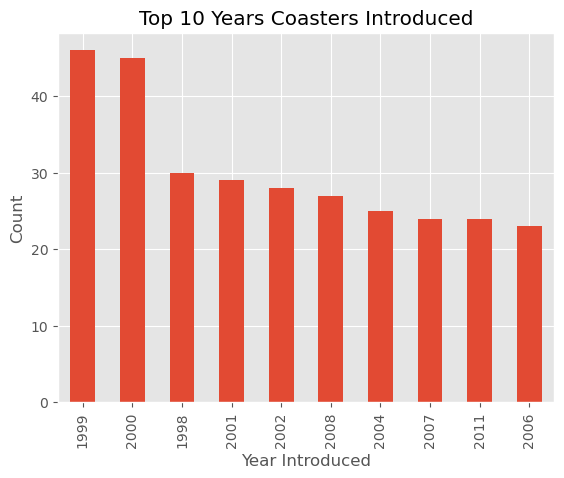

In [18]:
ax = df['Year_Introduced'].value_counts() \
    .head(10) \
    .plot(kind='bar', title='Top 10 Years Coasters Introduced')
ax.set_xlabel('Year Introduced')
ax.set_ylabel('Count')

Text(0.5, 0, 'Speed (mph)')

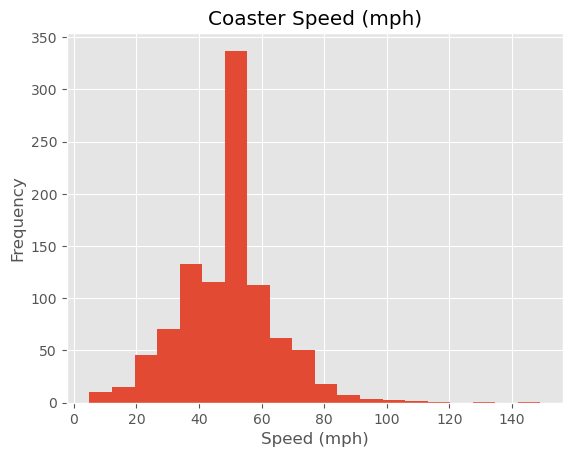

In [19]:
ax = df['Speed_mph'].plot(kind='hist',
                          bins=20,
                          title='Coaster Speed (mph)')
ax.set_xlabel('Speed (mph)')

In [20]:
df['Type_Main'].value_counts()

Type_Main
Steel    728
Wood     191
Other     71
Name: count, dtype: int64

# Step 4: Feature Relationships
- Scatterplot


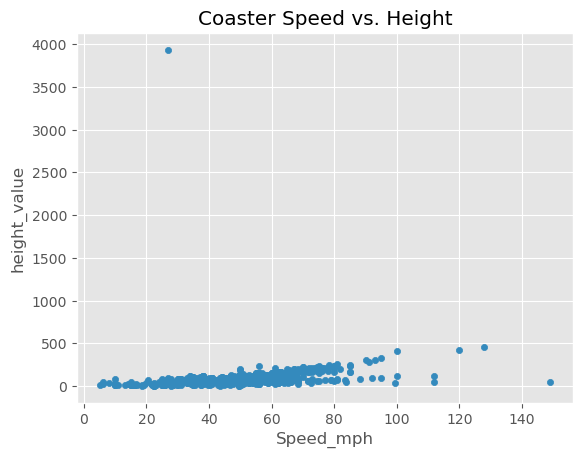

In [21]:
#df.plot(kind='scatter',
  #     x='Speed_mph',
    #    y='Height_ft',
    #    title='Coaster Speed vs. Height')
#plt.show()

df.plot(kind='scatter',
        x='Speed_mph',
        y='height_value',
        title='Coaster Speed vs. Height')
plt.show()


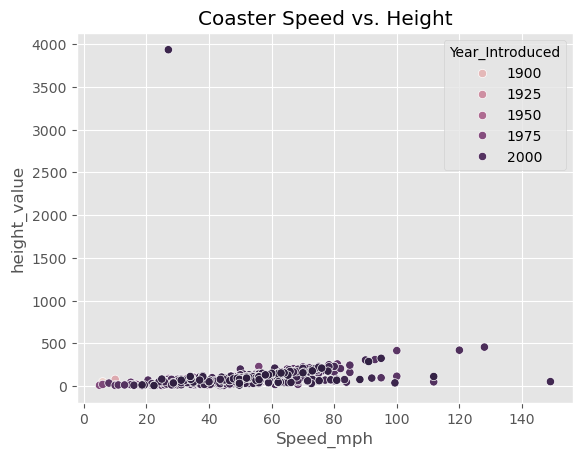

In [22]:
ax = sns.scatterplot(x='Speed_mph',
                y='height_value',
                hue='Year_Introduced',
                data=df)
ax.set_title('Coaster Speed vs. Height')
plt.show()

In [23]:
df_corr = df[['Year_Introduced','Speed_mph',
    'Inversions']].dropna().corr()
df_corr

,Year_Introduced,Speed_mph,Inversions,Inversions
Year_Introduced,1.000000,0.172879,0.233701,0.233701
Speed_mph,0.172879,1.000000,0.235854,0.235854
Inversions,0.233701,0.235854,1.000000,1.000000
Inversions,0.233701,0.235854,1.000000,1.000000




What are the locations with the fastest roller coasters (minimum of 10)?

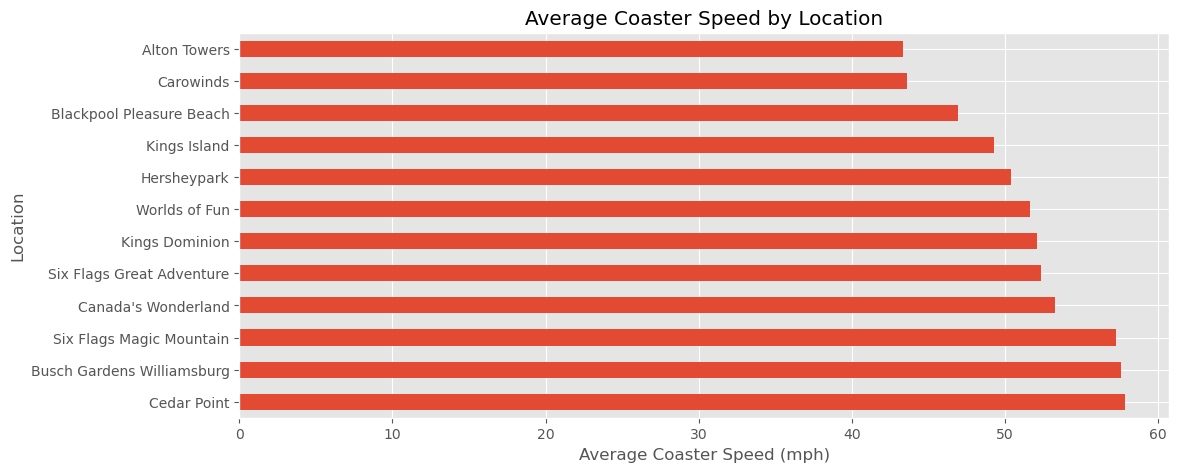

In [24]:
#ax = df.query('Location != "Other"') \
  #  .groupby('Location')['Speed_mph'] \
  #  .agg(['mean','count']) \
   # .query('count >= 10') \
  #  .sort_values('mean')['mean'] \
  #  .plot(kind='barh', figsize=(12, 5), title='Average Coast Speed by Location')
#ax.set_xlabel('Average Coaster Speed')
#plt.show()

#ax = df.query('Location != "Other"') \
#    .groupby('Location')['speed_mph'] \
#    .agg(['mean', 'count']) \
#    .query('count >= 10') \
#    .sort_values('mean', ascending=False)['mean'] \
#    .plot(kind='barh', figsize=(12, 5), title='Average Coaster Speed by Location')

#ax.set_xlabel('Average Coaster Speed (mph)')
#plt.show()


# Only keep rows where Location is not 'Other'
filtered_df = df[df['Location'] != 'Other']

# Group by Location and compute mean and count of speed_mph
grouped = filtered_df.groupby('Location')['Speed_mph'].agg(['mean', 'count'])

# Only keep locations where there are at least 10 coasters
filtered_grouped = grouped[grouped['count'] >= 10]

# Sort by mean speed, descending
sorted_grouped = filtered_grouped.sort_values('mean', ascending=False)

# Plot
ax = sorted_grouped['mean'].plot(kind='barh', figsize=(12, 5), title='Average Coaster Speed by Location')
ax.set_xlabel('Average Coaster Speed (mph)')
plt.show()


## 🔹 K-Nearest Neighbors (KNN) Implementation

In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:

df.head()


,Coaster_Name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,Type_Main,Opening_Date,speed1,speed2,speed1_value,speed1_unit,Speed_mph,height_value,height_unit,Inversions
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,48 in (122 cm),Lift Packed,...,Wood,1884-06-16,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,0
1,Flip Flap Railway,935 ft (285 m),50 mph (80 km/h),Sea Lion Park,Removed,1895,Wood,Lina Beecher,48 in (122 cm),Boomerang,...,Wood,1895-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1
2,Switchback Railway (Euclid Beach Park),935 ft (285 m),50 mph (80 km/h),"Cleveland, Ohio, United States",Closed,1972,Other,Vekoma,48 in (122 cm),Boomerang,...,Other,1999-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,0
3,Loop the Loop (Coney Island),935 ft (285 m),50 mph (80 km/h),Other,Removed,1901,Steel,Edwin Prescott,48 in (122 cm),Boomerang,...,Steel,1901-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1
4,Loop the Loop (Young's Pier),935 ft (285 m),50 mph (80 km/h),Other,Removed,1901,Steel,Edwin Prescott,48 in (122 cm),Boomerang,...,Steel,1901-01-01,50 mph,80 km/h,50.0,mph,49.7,79.0,ft,1


In [27]:
df.Manufacturer.unique

<bound method Series.unique of 0           LaMarcus Adna Thompson
1                     Lina Beecher
2                           Vekoma
3                   Edwin Prescott
4                   Edwin Prescott
                  ...             
985                  Premier Rides
986             Martin & Vleminckx
987                        Intamin
988      S&S – Sansei Technologies
989    Rocky Mountain Construction
Name: Manufacturer, Length: 990, dtype: object>

In [28]:
df.isna().sum()

Coaster_Name          0
Length                0
Speed                 0
Location              0
Status                0
Opening date          0
Type                  0
Manufacturer          0
Height restriction    0
Model                 0
Height                0
Inversions            0
Lift/launch system    0
Trains                0
Duration              0
Capacity              0
Designer              0
Year_Introduced       0
latitude              0
longitude             0
Type_Main             0
Opening_Date          0
speed1                0
speed2                0
speed1_value          0
speed1_unit           0
Speed_mph             0
height_value          0
height_unit           0
Inversions            0
dtype: int64

In [ ]:

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = X.select_dtypes(exclude=['datetime64[ns]'])


X = pd.get_dummies(X, drop_first=True)

if y.dtypes == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)


y_pred = knn.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.6313131313131313

Confusion Matrix:
 [[116   0   1   0   0   0   0   0   0]
 [ 11   0   0   0   0   0   0   0   0]
 [ 15   0   3   0   0   0   0   0   0]
 [ 18   0   0   1   0   0   0   0   0]
 [ 11   0   0   0   0   0   0   0   0]
 [  6   0   0   0   0   2   0   0   0]
 [  2   0   0   1   0   0   3   0   0]
 [  7   0   0   0   0   0   0   0   0]
 [  1   0   0   0   0   0   0   0   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.99      0.76       117
           1       0.00      0.00      0.00        11
           2       0.75      0.17      0.27        18
           3       0.50      0.05      0.10        19
           4       0.00      0.00      0.00        11
           5       1.00      0.25      0.40         8
           6       1.00      0.50      0.67         6
           7       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         1

    accuracy                  

c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:

# Train KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6313131313131313

Confusion Matrix:
 [[116   0   1   0   0   0   0   0   0]
 [ 11   0   0   0   0   0   0   0   0]
 [ 15   0   3   0   0   0   0   0   0]
 [ 18   0   0   1   0   0   0   0   0]
 [ 11   0   0   0   0   0   0   0   0]
 [  6   0   0   0   0   2   0   0   0]
 [  2   0   0   1   0   0   3   0   0]
 [  7   0   0   0   0   0   0   0   0]
 [  1   0   0   0   0   0   0   0   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.99      0.76       117
           1       0.00      0.00      0.00        11
           2       0.75      0.17      0.27        18
           3       0.50      0.05      0.10        19
           4       0.00      0.00      0.00        11
           5       1.00      0.25      0.40         8
           6       1.00      0.50      0.67         6
           7       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         1

    accuracy                    

c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Purnank\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


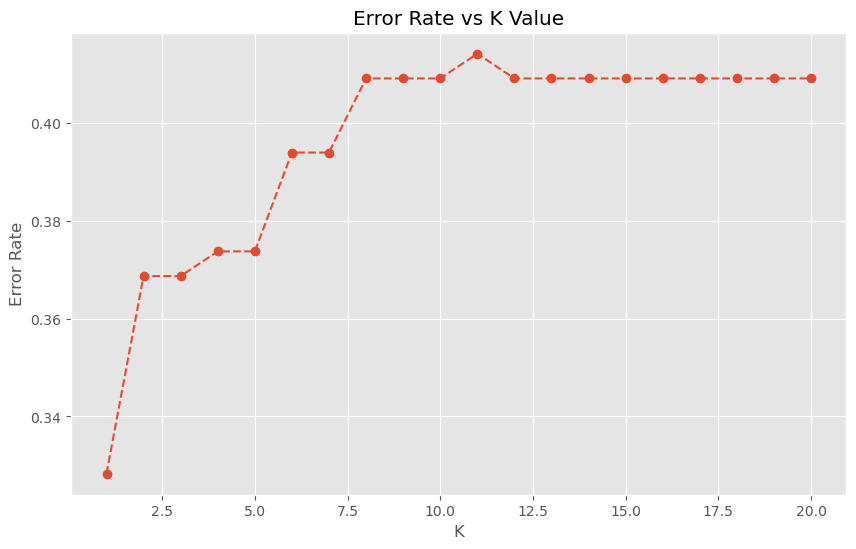

In [31]:

# Find best K value
error_rates = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rates.append(np.mean(pred_k != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rates, marker='o', linestyle='--')
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()
